# Optimal locking-aware prolongators
==========================================

For the Timoshenko beam, I was using the standard prolongator of FEA basis (1D-Lagrange) in both [w, th]. 
However, there was no coupling in the prolongation between [w, th] so that gam = w_{,x} + th are poorly interpolated.
I will now revisit making optimal locking-aware prolongators as opposed to optimizing directly the stiffness matrix..
I will compare this with AMGe as well as it may be equivalent in EB-limit?

* Motivation: My previous IGA method with DRIG (Derham) element allows gam = w_{,x} + th = 0 at discrete level by different IGA orders for [w, th].
That works for plate as well, but not quite for cylinder.. the membrane locking constraint is very hard to discretely allow (may not work without some crazy mixed-FEA method). So here I'm trying a new method working up from beams to plates to shells again to see if locking-aware prolongator can greatly improve the GMG performance with
standard elements (or some minor modification of element-formulation too).

For the Timoshenko beam the prolongator consists of [P_w, P_th], but we want to check interp of gam_c => gam_f the trv shear strains (which are one fewer DOF and
take up an edge-space). I propose to do this by defining discrete matrix operators as follows:

gam_f = G_f * u_f
gam_c = G_c * u_c
u_f = P * u_c
gam_f = P_gam * gam_c  where P_gam is some desired interp

This actually constructs a new DeRham diagram in matrix prolongator interpolations..

u_c ==== P ====> u_f
 =                =
G_c              G_f
 =                =
gam_c = P_gam => gam_f 

If P_gam is desired gam prolongation, say of 1D-Lagrange on edge DOF, then we'd want to constrain P to match P_gam as best as possible.
Namely, we'd have:   G_f * P ~= P_gam * G_c  (Derham equation)

If we have some P ~ P_0 tentative prolongator from FEA basis where [w, th] prolong are uncoupled. We might modify P to match P_gam better using
weak constraints. Namely,

min_P ||G_f * P - P_gam * G_c||_F^2 + lam * ||P - P_0||^2  for some lam Lagrange multiplier.

We would then have a least-squares problem (stacked):
[G_f; sqrt(lam)*I] * P = [P_gam * G_c; sqrt(lam)*P_0]
equiv to
A * P = B stacked system.

Then we have P = A^{pinv} * B, which can be exactly solved for this system as a function of lam.

P^* = (G_f^T * G_f + lam * I)^{-1} * (G_f^T * P_gam * G_c + lam * P_0)

How does this compare with an AMGe method? And there are other KKT equations or weak-formulations that are possible. Anyways as long as P ~ P_0
and G_f * P ~ P_gam * G_c, we will be good I think. But maybe P ~ P_0 is not the best way to do that.. see if weak way to discover P_0 and use that instead.

In [ ]:
# let's now construct some of these discrete operators for a small beam problem..
# do one element first
nxe_c = 1; nxe_f = 2
nx_c = 2; nx_f = 3
import numpy as np

# initial prolongator for 1st order Lagrange
P_0 = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0.5, 0, 0.5, 0],
    [0, 0.5, 0, 0.5],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

# discrete trv shear strain operators G_c, G_f where gam = (w_{i+1} - w_i) / dx + 0.5 * (th_i + th_{i+1})
dx_c = 1.0; dx_f = 0.5
a_c = 1.0/dx_c; a_f = 1.0/dx_f

G_c = np.array([
    [-a_c, 0.5, a_c, 0.5]
])

G_f = np.array([
    [-a_f, 0.5, a_f, 0.5, 0, 0],
    [0, 0, -a_f, 0.5, a_f, 0.5]
])

# then desired prolongator for the trv shear strains
P_gam = np.array([
    [1.0], [1.0]
]) # for this simple case it just ends up being injection cause only one edge DOF..
# for more DOF it would have averaging when more coarse edges.. and interior fine edges

# print(f"{G_c.shape=} {G_f.shape=} {P_gam.shape=}")

G_c.shape=(1, 4) G_f.shape=(2, 6) P_gam.shape=(2, 1)


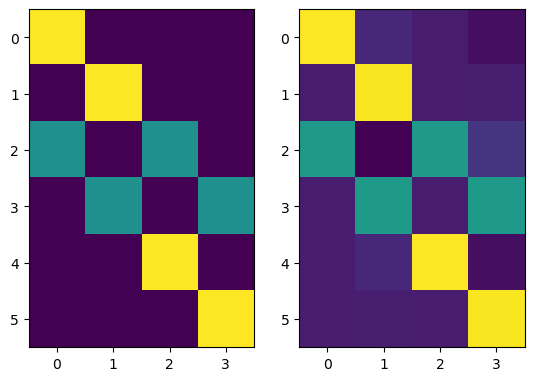

rel_resid=0.0008156606851437154


In [ ]:
# now we're gonna try and solve an approx least-squares problem..

# lam = 1.0
# lam = 0.1
lam = 1e-2 # lower lam value results in more accurate trv shear strain interp..
P = np.linalg.inv(G_f.T @ G_f + np.eye(6) * lam) @ (G_f.T @ P_gam @ G_c + lam * P_0)
# how to do the inverse in harder problem though? local operators still and assemble it?
# maybe can invert it locally and then assemble it the same way (I do inverse in the IGA prolong devel and then assemble it)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2)
ax[0].imshow(P_0)
ax[1].imshow(P)
plt.show()

# check how much error in DeRham constraint?
DR_resid_0 = G_f @ P_0 - P_gam @ G_c
DR_resid = G_f @ P - P_gam @ G_c
rel_resid = np.linalg.norm(DR_resid) / np.linalg.norm(DR_resid_0)
print(f"{rel_resid=}")
# worked quite well resid in DeRham constraint is like 8e-4 (very small, can change lam to make it more accurate)
# anyways, I think I might be able to do a general assembly (will have to solve prolong stencil for interior and bndry nodes)
# still have to check that hte aswsembly works.. and can be assembled without changing gam...

# NOTE : may also have to add BCs like e_1^T * P = 0 and e_N^T * P = 0 constraints
# otherwise DeRham system of eqns and changing P from P_0 may break BCs.
# re-enforcing BCs with projector would then break DeRham eqns near BCs. So need to include in system of eqns.

# even if local stencil assembly doesn't work for good P_gam.. I could maybe solve this as opt problem like with SPAI or just solve the linear system 
# with CSR matrix and ILU or something? It's a simple linear system to invert (G_f^T * G_f + lam * I) probably..

In [ ]:
# CHECK AND SEE IF WE CAN do a local assembly of the prolongation stencils instead of global

